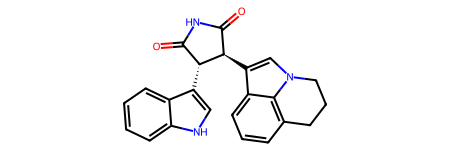

In [5]:
from rdkit import Chem
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import Draw
IPythonConsole.ipython_useSVG=True  #< set this to False if you want PNGs instead of SVGs
def mol_with_atom_index(mol): ##给原子标号
    for atom in mol.GetAtoms():
        atom.SetAtomMapNum(atom.GetIdx())
    return mol
# Test in a kinase inhibitor
mol = Chem.MolFromSmiles("C1CC2=C3C(=CC=C2)C(=CN3C1)[C@H]4[C@@H](C(=O)NC4=O)C5=CNC6=CC=CC=C65")
# Default
mol

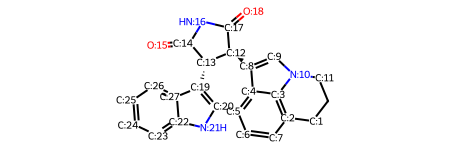

In [6]:
mol_with_atom_index(mol)

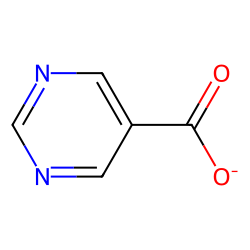

In [8]:
from rdkit.Chem import AllChem
IPythonConsole.molSize=250,250
m = Chem.MolFromSmiles('c1ncncc1C(=O)[O-]')
AllChem.ComputeGasteigerCharges(m)
m

In [9]:
AllChem.GetMorganFingerprintAsBitVect(m, radius=2, nBits=2048)

In [11]:
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
import numpy as np

smiles_list = ['CCO', 'CCCO', 'c1ccccc1', 'CC(=O)O']
mols = [Chem.MolFromSmiles(s) for s in smiles_list]

# 1. 创建一次生成器
generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

# 2. 批量生成 (列表推导式)
fps = [generator.GetFingerprint(m) for m in mols if m is not None]

# 3. 转换为 Numpy 数组 (用于机器学习)
# 新的指纹对象同样支持 ConvertToNumpyArray
from rdkit import DataStructs

fp_matrix = np.zeros((len(fps), 2048), dtype=int)
for i, fp in enumerate(fps):
    DataStructs.ConvertToNumpyArray(fp, fp_matrix[i])

print(f"生成的特征矩阵形状: {fp_matrix.shape}")

生成的特征矩阵形状: (4, 2048)
